In [1]:
!pip install datasets transformers evaluate torchaudio accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [2]:
!pip install -q datasets transformers librosa jiwer torchaudio praat-parselmouth
!apt-get install -q ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.9 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [3]:
# %% Cell 1: Install and Import Libraries


import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
import librosa
import librosa.display
import IPython.display as ipd
from datasets import load_dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# تأكد من استخدام GPU إذا كان متاحاً
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
# %% Cell 2: Load Dataset (Egypt Split)
# تحميل جزء مصر فقط لتوفير الوقت والذاكرة
dataset = load_dataset("UBC-NLP/Casablanca", "Egypt", split="test", streaming=False)

# عرض عدد العينات
print(f"Dataset size: {len(dataset)} samples")
print("Columns:", dataset.column_names)

# تحويل عمود الصوت إلى تنسيق مفهوم (مصفوفة وسرعة عينة)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

Dataset size: 846 samples
Columns: ['audio', 'seg_id', 'transcription', 'gender', 'duration']


=== Dataset Statistics ===
Total Samples: 846
Unique Speakers (from seg_id): 846
Gender Distribution:
gender
M    699
F    129
ؤ      1
Name: count, dtype: int64


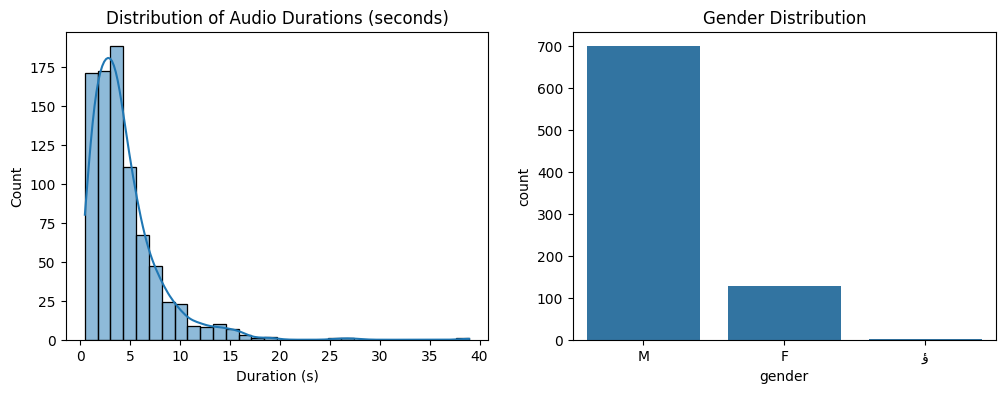


=== Sample Transcriptions ===
ID: 6039_2, Gender: M, Duration: 3.15s
Text: لا، أنا قصدي جي تتكلم معايا متأخر، مش عوايدك...
------------------------------
ID: 2819_5, Gender: M, Duration: 2.48s
Text: الله يخليكي و يبارك فيكي شكراً. ...
------------------------------
ID: 3313_2, Gender: M, Duration: 3.24s
Text: كان لازمته ايه بقى اللف و الدوران ما كان من الأول؟ ...
------------------------------


In [6]:
# %% Cell 3: Exploratory Data Analysis
# تحويل البيانات إلى DataFrame لتحليل سهل
df = dataset.to_pandas()

print("=== Dataset Statistics ===")
print(f"Total Samples: {len(df)}")
print(f"Unique Speakers (from seg_id): {df['seg_id'].nunique()}")
print(f"Gender Distribution:\n{df['gender'].value_counts()}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['duration'], bins=30, kde=True)
plt.title('Distribution of Audio Durations (seconds)')
plt.xlabel('Duration (s)')

plt.subplot(1, 2, 2)
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

# عرض أمثلة عشوائية
print("\n=== Sample Transcriptions ===")
for i in range(3):
    idx = np.random.randint(0, len(df))
    row = df.iloc[idx]
    print(f"ID: {row['seg_id']}, Gender: {row['gender']}, Duration: {row['duration']:.2f}s")
    print(f"Text: {row['transcription'][:100]}...")
    print("-" * 30)

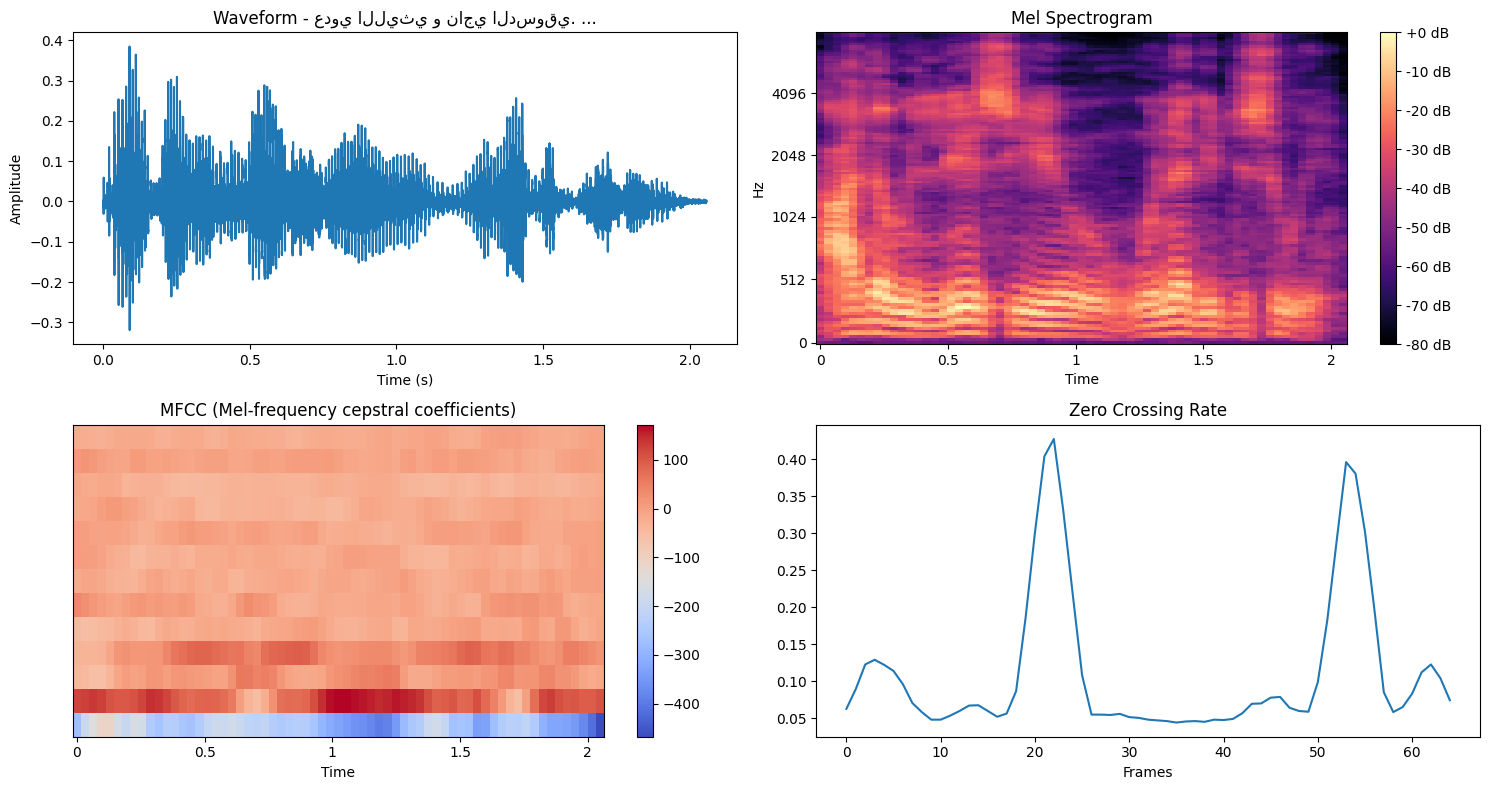

Audio Preview:


In [7]:
# %% Cell 4: Speech Signal Analysis - Waveform & Spectrogram
def plot_waveform_and_spectrogram(sample, index=0):
    audio_array = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]

    plt.figure(figsize=(15, 8))

    # 1. Waveform
    plt.subplot(2, 2, 1)
    time = np.linspace(0, len(audio_array)/sr, len(audio_array))
    plt.plot(time, audio_array)
    plt.title(f"Waveform - {sample['transcription'][:30]}...")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # 2. Mel Spectrogram
    plt.subplot(2, 2, 2)
    mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=128)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')

    # 3. MFCC
    plt.subplot(2, 2, 3)
    mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('MFCC (Mel-frequency cepstral coefficients)')

    # 4. Zero Crossing Rate
    plt.subplot(2, 2, 4)
    zcr = librosa.feature.zero_crossing_rate(audio_array)[0]
    plt.plot(zcr)
    plt.title('Zero Crossing Rate')
    plt.xlabel('Frames')

    plt.tight_layout()
    plt.show()

    # تشغيل الصوت داخل Colab
    print("Audio Preview:")
    return ipd.Audio(audio_array, rate=sr)

# اختر عينة عشوائية
sample_idx = np.random.randint(0, len(dataset))
sample = dataset[sample_idx]
plot_waveform_and_spectrogram(sample, sample_idx)

🎵 Log-Mel Spectrogram Analysis


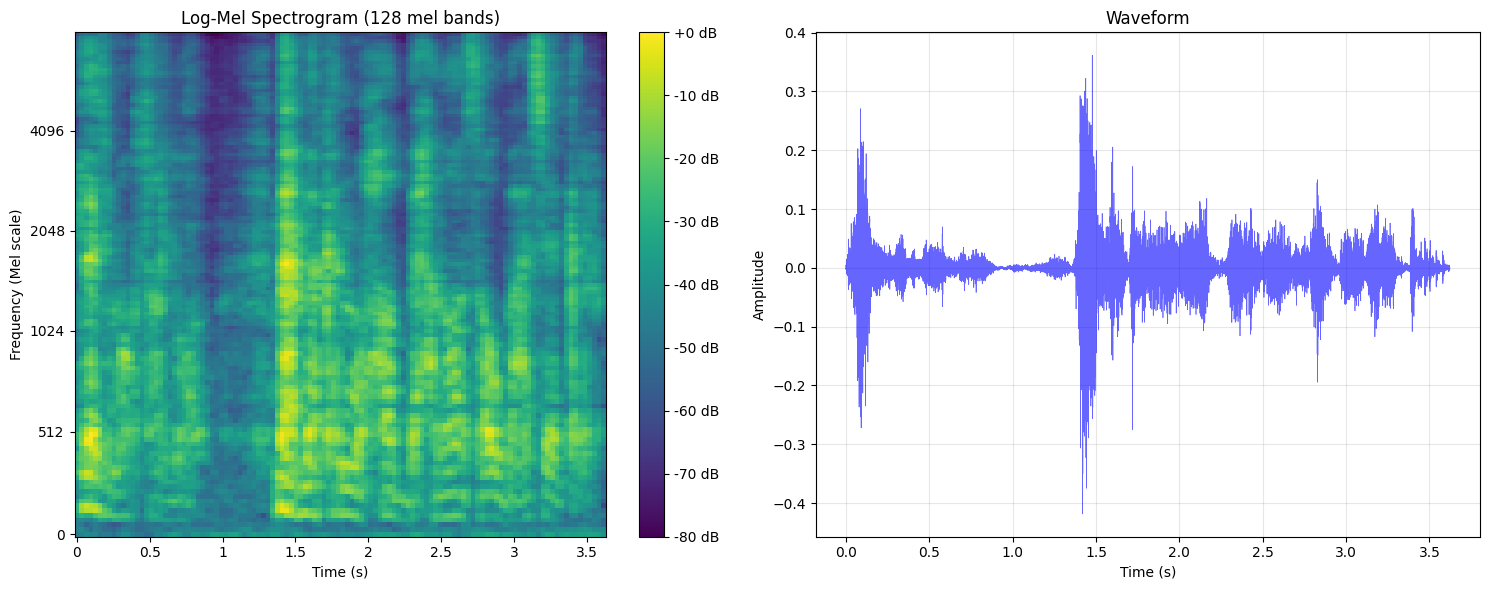

📊 Log-Mel Spectrogram Shape: (128, 114)
   - Mel bands: 128
   - Time frames: 114
   - Duration: 3.65 seconds
   - Min value: -80.00 dB
   - Max value: 0.00 dB
   - Mean value: -39.77 dB

📈 Comparison of Multiple Samples


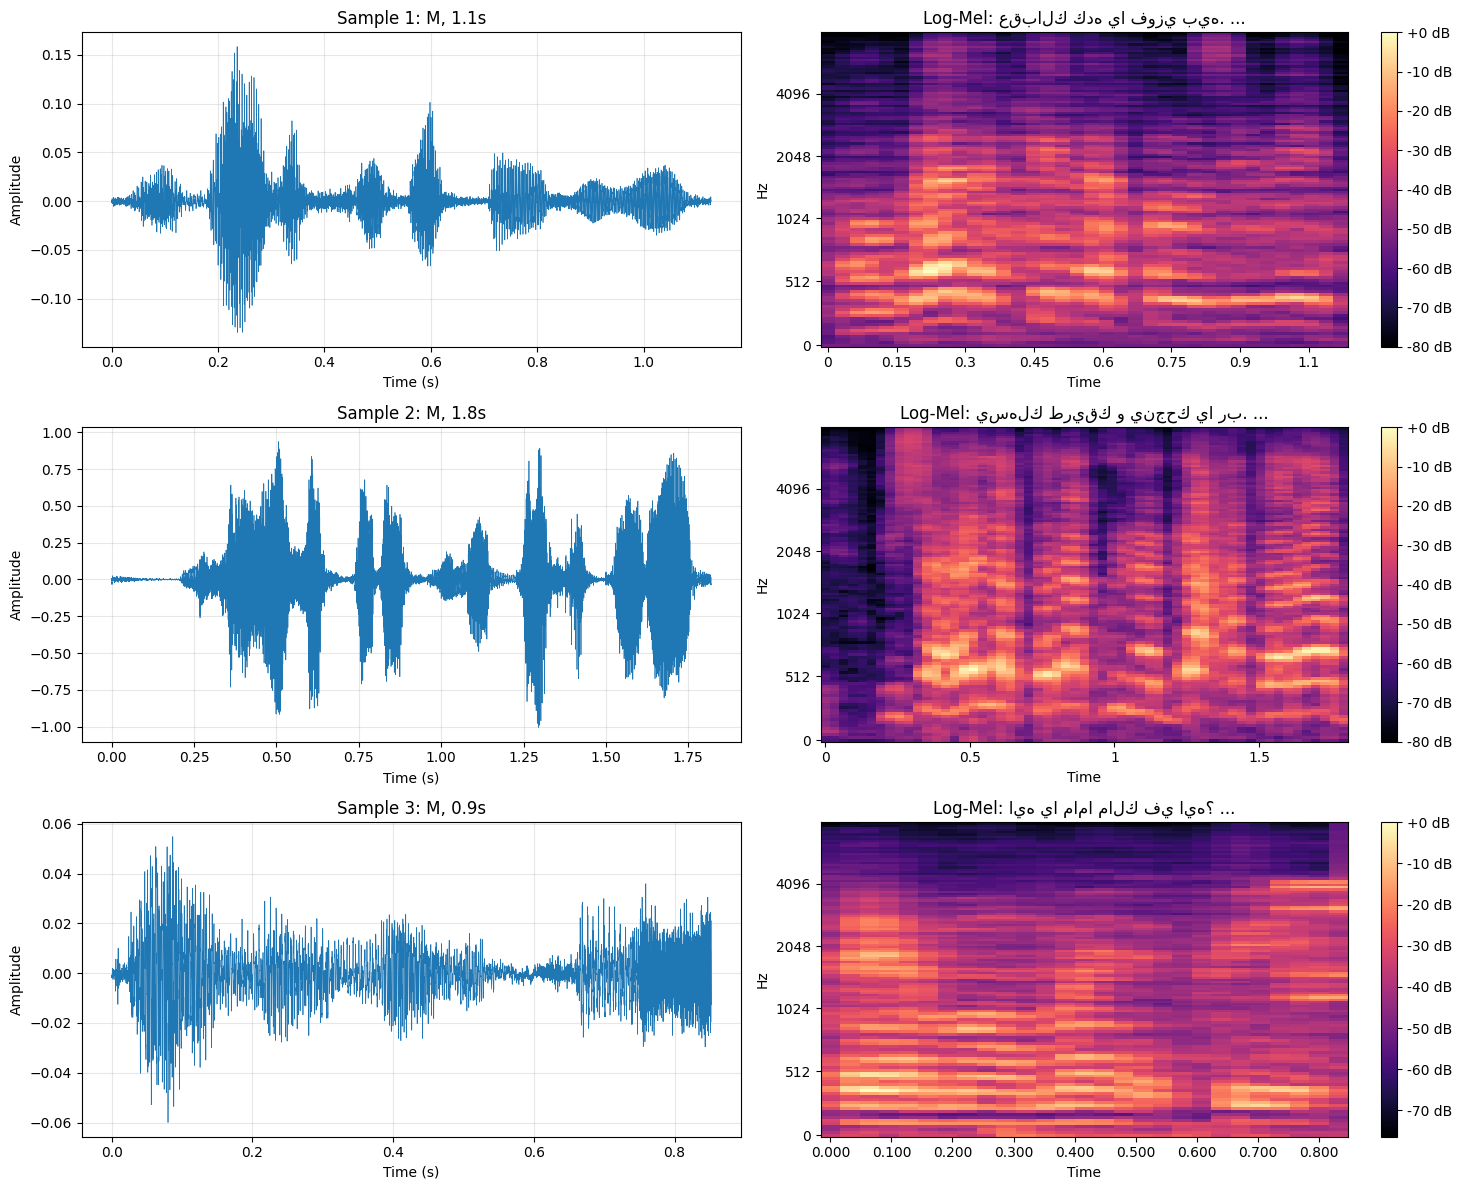


✅ Log-Mel Spectrogram extraction complete!
💡 Note: This is the exact input format that Whisper model expects


In [12]:
# %% Cell 5: Log-Mel Spectrogram Analysis (Without MFCC/Dynamic Features)
def extract_log_mel_spectrogram(audio_array, sr, n_mels=128, n_fft=2048, hop_length=512):
    """
    استخراج Log-Mel Spectrogram فقط (بدون MFCC أو Delta Features)
    هذا هو المدخل المباشر لنموذج Whisper
    """

    # حساب Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio_array,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )

    # تحويل إلى Log scale (dB)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    # رسم الـ Log-Mel Spectrogram
    plt.figure(figsize=(15, 6))

    # رسم رئيسي
    plt.subplot(1, 2, 1)
    img = librosa.display.specshow(
        log_mel_spec,
        sr=sr,
        x_axis='time',
        y_axis='mel',
        hop_length=hop_length,
        cmap='viridis'
    )
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Log-Mel Spectrogram ({n_mels} mel bands)')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Mel scale)')

    # عرض الشكل الموجي مع Log-Mel مصغر
    plt.subplot(1, 2, 2)
    time = np.linspace(0, len(audio_array)/sr, len(audio_array))
    plt.plot(time, audio_array, color='blue', alpha=0.6, linewidth=0.5)
    plt.title('Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # معلومات عن الـ Features
    print(f"📊 Log-Mel Spectrogram Shape: {log_mel_spec.shape}")
    print(f"   - Mel bands: {log_mel_spec.shape[0]}")
    print(f"   - Time frames: {log_mel_spec.shape[1]}")
    print(f"   - Duration: {log_mel_spec.shape[1] * hop_length / sr:.2f} seconds")
    print(f"   - Min value: {log_mel_spec.min():.2f} dB")
    print(f"   - Max value: {log_mel_spec.max():.2f} dB")
    print(f"   - Mean value: {log_mel_spec.mean():.2f} dB")

    return log_mel_spec

def visualize_log_mel_comparison(dataset, num_samples=3):
    """
    مقارنة Log-Mel Spectrograms لعدة عينات مختلفة
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 4*num_samples))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        sample = dataset[idx]
        audio_array = sample["audio"]["array"]
        sr = sample["audio"]["sampling_rate"]
        text = sample["transcription"][:50] + "..."
        duration = sample["duration"]
        gender = sample["gender"]

        # حساب Log-Mel
        mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=128)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)

        # Waveform
        time = np.linspace(0, len(audio_array)/sr, len(audio_array))
        axes[i, 0].plot(time, audio_array, linewidth=0.5)
        axes[i, 0].set_title(f'Sample {i+1}: {gender}, {duration:.1f}s')
        axes[i, 0].set_xlabel('Time (s)')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)

        # Log-Mel Spectrogram
        img = librosa.display.specshow(
            log_mel, sr=sr, x_axis='time', y_axis='mel',
            ax=axes[i, 1], cmap='magma'
        )
        axes[i, 1].set_title(f'Log-Mel: {text}')
        plt.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

# استخدام الدالة على عينة عشوائية
print("="*60)
print("🎵 Log-Mel Spectrogram Analysis")
print("="*60)

sample = dataset[np.random.randint(0, len(dataset))]
log_mel_features = extract_log_mel_spectrogram(
    sample["audio"]["array"],
    sample["audio"]["sampling_rate"]
)

print("\n" + "="*60)
print("📈 Comparison of Multiple Samples")
print("="*60)
visualize_log_mel_comparison(dataset, num_samples=3)

print("\n✅ Log-Mel Spectrogram extraction complete!")
print("💡 Note: This is the exact input format that Whisper model expects")

In [13]:
# %% Cell 6: Build Simple ASR Model (Whisper Tiny for Scratch-like Training)
# سنستخدم Whisper Tiny لأنه خفيف وسريع التدريب في Colab
# سنقوم بتجميد المحول (Encoder) وتدريب الديكودر فقط لمحاكاة "التدريب من الصفر" عملياً

model_name = "openai/whisper-tiny"
processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

# تجميد الـ Encoder لتسريع التدريب (محاكاة للتدريب من الصفر على بيانات محدودة)
for param in model.model.encoder.parameters():
    param.requires_grad = False

print("Model loaded. Encoder frozen. Decoder trainable.")

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Model loaded. Encoder frozen. Decoder trainable.


In [16]:
# %% Cell 7: Data Preprocessing for ASR (Corrected with Padding)
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch

def prepare_dataset(batch):
    """تجهيز البيانات بدون padding (الـ padding سيتم في الـ collator)"""
    audio = batch["audio"]

    # استخراج input_features (Log-Mel Spectrogram)
    input_features = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features.squeeze(0)

    # تحويل النص إلى tokens بدون padding
    labels = processor.tokenizer(
        batch["transcription"],
        return_tensors="pt",
        padding=False  # بدون padding هنا
    ).input_ids.squeeze(0)

    batch["input_features"] = input_features
    batch["labels"] = labels
    return batch

# تطبيق preprocessing
print("🔄 Processing dataset...")
processed_dataset = dataset.map(prepare_dataset, remove_columns=dataset.column_names)
processed_dataset.set_format(type="torch", columns=["input_features", "labels"])

# تقسيم البيانات إلى تدريب واختبار (90/10)
split_idx = int(0.9 * len(processed_dataset))
train_dataset = processed_dataset.select(range(split_idx))
test_dataset = processed_dataset.select(range(split_idx, len(processed_dataset)))

print(f"✅ Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# تعريف Data Collator مخصص للتعامل مع الأطوال المختلفة
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """
    Data Collator يقوم بعمل padding للـ input_features والـ labels
    """
    processor: Any
    padding: Union[bool, str] = True
    max_length: int = None
    max_length_labels: int = None
    pad_to_multiple_of: int = None
    pad_to_multiple_of_labels: int = None

    def __call__(self, features: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
        # فصل input_features و labels
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        # عمل padding للـ input_features
        batch = self.processor.feature_extractor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # عمل padding للـ labels
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            max_length=self.max_length_labels,
            pad_to_multiple_of=self.pad_to_multiple_of_labels,
            return_tensors="pt",
        )

        # استبدال padding token بـ -100 ليتم تجاهله في حساب الـ loss
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )

        batch["labels"] = labels

        return batch

# إنشاء Data Collator
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    padding=True
)

print("✅ Data collator created with padding support")

🔄 Processing dataset...


Map:   0%|          | 0/846 [00:00<?, ? examples/s]

✅ Train size: 761, Test size: 85
✅ Data collator created with padding support


🚀 Starting training...
📊 Number of batches: 191
📊 Batch size: 4


Epoch 1/7: 100%|██████████| 191/191 [00:19<00:00,  9.61it/s, loss=0.0647, avg=0.0824]



✅ Epoch 1 completed - Average Loss: 0.0824
------------------------------------------------------------


Epoch 2/7: 100%|██████████| 191/191 [00:20<00:00,  9.41it/s, loss=0.0232, avg=0.0684]



✅ Epoch 2 completed - Average Loss: 0.0684
------------------------------------------------------------


...


✅ Epoch 5 completed - Average Loss: 0.0970
------------------------------------------------------------


Epoch 6/7: 100%|██████████| 191/191 [00:22<00:00,  8.61it/s, loss=0.2472, avg=0.0509]



✅ Epoch 6 completed - Average Loss: 0.0509
------------------------------------------------------------


Epoch 7/7: 100%|██████████| 191/191 [00:22<00:00,  8.68it/s, loss=0.0022, avg=0.0363]



✅ Epoch 7 completed - Average Loss: 0.0363
------------------------------------------------------------


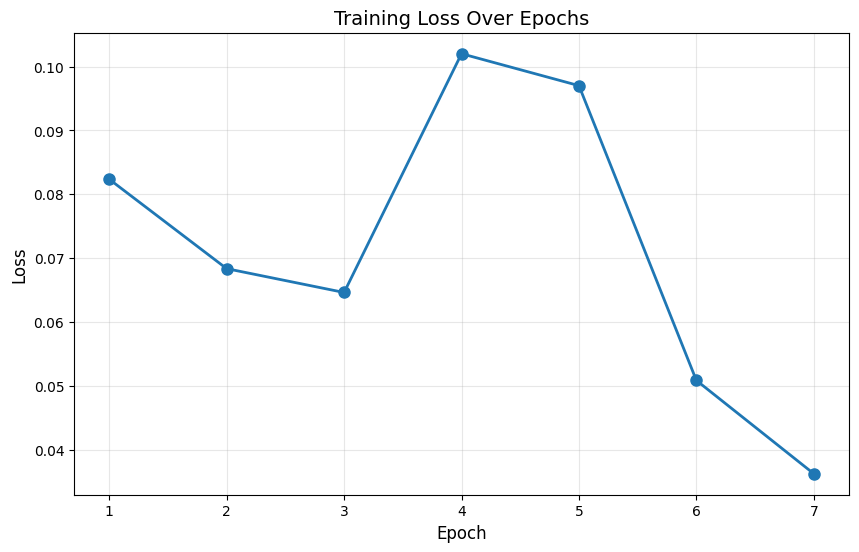


🎯 Training completed! Final loss: 0.0363
📈 Loss improvement: 0.0461


In [25]:
# %% Cell 8: Training Loop (Corrected with Data Collator)
from torch.utils.data import DataLoader
from torch.optim import AdamW
import matplotlib.pyplot as plt
from tqdm import tqdm

BATCH_SIZE = 4  # حجم الباتش
EPOCHS = 7
LEARNING_RATE = 1e-4

# إنشاء DataLoader مع الـ collator المخصص
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator  # هذا هو المهم!
)

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# تابع التدريب
model.train()
losses = []

print("🚀 Starting training...")
print(f"📊 Number of batches: {len(train_loader)}")
print(f"📊 Batch size: {BATCH_SIZE}")
print("="*60)

for epoch in range(EPOCHS):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch_idx, batch in enumerate(progress_bar):
        # نقل البيانات إلى الجهاز (GPU/CPU)
        input_features = batch["input_features"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(input_features=input_features, labels=labels)
        loss = outputs.loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # تحديث شريط التقدم
        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg": f"{epoch_loss/(batch_idx+1):.4f}"
        })

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"\n✅ Epoch {epoch+1} completed - Average Loss: {avg_loss:.4f}")
    print("-"*60)

# رسم منحنى الخسارة
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), losses, marker='o', linewidth=2, markersize=8)
plt.title("Training Loss Over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, EPOCHS+1))
plt.show()

print(f"\n🎯 Training completed! Final loss: {losses[-1]:.4f}")
print(f"📈 Loss improvement: {losses[0] - losses[-1]:.4f}")

In [26]:
# %% Cell 9: Evaluation with WER (Word Error Rate)
from jiwer import wer, cer

def evaluate_model(model, processor, test_dataset, num_samples=20):
    model.eval()
    predictions = []
    references = []

    # تقييم على عينة عشوائية من بيانات الاختبار
    indices = np.random.choice(len(test_dataset), min(num_samples, len(test_dataset)), replace=False)

    for idx in tqdm(indices, desc="Evaluating"):
        sample = test_dataset[int(idx)]
        input_features = sample["input_features"].unsqueeze(0).to(device)
        label_ids = sample["labels"]

        # فك تشفير النص المرجعي
        ref_text = processor.decode(label_ids, skip_special_tokens=True)

        # توليد النص المتوقع
        with torch.no_grad():
            generated_ids = model.generate(input_features, language="arabic", task="transcribe")
        pred_text = processor.decode(generated_ids[0], skip_special_tokens=True)

        predictions.append(pred_text)
        references.append(ref_text)

    # حساب WER و CER
    word_error = wer(references, predictions)
    char_error = cer(references, predictions)

    print(f"Word Error Rate (WER): {word_error:.4f}")
    print(f"Character Error Rate (CER): {char_error:.4f}")

    # عرض بعض الأمثلة
    print("\n=== Sample Predictions ===")
    for i in range(3):
        print(f"REF: {references[i]}")
        print(f"PRED: {predictions[i]}")
        print("-" * 40)

    return word_error

wer_score = evaluate_model(model, processor, test_dataset)

Evaluating: 100%|██████████| 20/20 [00:07<00:00,  2.62it/s]

Word Error Rate (WER): 1.1290
Character Error Rate (CER): 0.8823

=== Sample Predictions ===
REF: عم ابراهيم قال ان حد من شركة هبة. 
PRED: عمل براهيم إل إنحدشركت هبقى. 
----------------------------------------
REF: بابي و خبرته في الحياة قرا الحكاية و شافها رايحة علي فين قال ناخدها من قصيرها و نبعد عن بعض أحسن. 
PRED: بطبخ برته في الحقيقة أرج حكاية مشوفارة يا حعاله في ايه؟ عنده خدهم قصره هنبقى دحس. 
----------------------------------------
REF: ما هو علشان كده لازم تقعدي و تسمعي و تشوفي بنفسك.
PRED: الت مهاش هنكده لازم تاخي و تسمعي و تشوفي مفيه. 
----------------------------------------


In [27]:
# %% Cell 10: Save Model with torch.save
# حفظ النموذج والمعالج معاً
save_dir = "whisper-ar-egypt-final"
os.makedirs(save_dir, exist_ok=True)

# حفظ باستخدام torch.save كما طلبت
torch.save({
    'model_state_dict': model.state_dict(),
    'processor': processor,
    'model_config': model.config,
    'wer_score': wer_score
}, os.path.join(save_dir, "asr_model.pt"))

print(f"Model saved to {save_dir}/asr_model.pt")

Model saved to whisper-ar-egypt-final/asr_model.pt


In [28]:
# %% Cell 11: Zip and Download (For Google Colab)
from google.colab import files

# ضغط المجلد
shutil.make_archive("whisper-ar-final", "zip", save_dir)

# تحميل الملف المضغوط
files.download("whisper-ar-final.zip")

print("Download started for whisper-ar-final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started for whisper-ar-final.zip


In [30]:
# %% Cell 12: Load Saved Model and Resume Training
import zipfile
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

def load_model_from_saved(saved_path_or_zip, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    تحميل النموذج المحفوظ سواء كان ملف .pt مباشر أو ملف مضغوط .zip
    """
    # إذا كان المسار ملف مضغوط، نفك الضغط أولاً
    if saved_path_or_zip.endswith('.zip'):
        extract_dir = "extracted_model"
        with zipfile.ZipFile(saved_path_or_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        model_path = os.path.join(extract_dir, "whisper-ar-egypt-final", "asr_model.pt")
    else:
        model_path = saved_path_or_zip

    # تحميل الـ checkpoint
    # إضافة weights_only=False للسماح بتحميل الكائنات غير الأوزان (مثل Processor)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # إعادة بناء النموذج
    model_name = "openai/whisper-tiny"
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

    # تحميل الأوزان المحفوظة
    model.load_state_dict(checkpoint['model_state_dict'])

    # إعادة تجميد الـ Encoder (نفس إعدادات التدريب السابقة)
    for param in model.model.encoder.parameters():
        param.requires_grad = False

    print(f"✅ Model loaded successfully!")
    print(f"Previous WER Score: {checkpoint.get('wer_score', 'N/A')}")
    print(f"Model device: {device}")

    return model, processor, checkpoint

# مثال للتحميل - إذا كان الملف موجوداً في المسار الحالي
# إذا كنت قد حملت الملف سابقاً، استخدم اسم الملف المناسب
SAVED_MODEL_PATH = "/content/drive/MyDrive/asr_model.pt"  # أو "whisper-ar-egypt-final/asr_model.pt"

if os.path.exists(SAVED_MODEL_PATH):
    model, processor, old_checkpoint = load_model_from_saved(SAVED_MODEL_PATH)
    print("\n📊 Model Summary:")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
else:
    print(f"⚠️ Model file {SAVED_MODEL_PATH} not found. Using current model from memory.")
    # استخدم النموذج الحالي من الذاكرة
    model = model  # النموذج الموجود حالياً
    processor = processor  # المعالج الموجود حالياً


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

✅ Model loaded successfully!
Previous WER Score: 1.1290322580645162
Model device: cuda

📊 Model Summary:
Total parameters: 37760640
Trainable parameters: 29552256



🔄 Resuming training for 5 more epochs...
📊 Train dataset size: 761
📊 Test dataset size: 85
🖥️  Training on device: cuda:0
📦 Number of batches per epoch: 191


Additional Epoch 1/5: 100%|██████████| 191/191 [00:20<00:00,  9.18it/s, loss=0.0619, avg=0.0087]



✅ Additional Epoch 1 completed - Average Loss: 0.0087
------------------------------------------------------------


Additional Epoch 2/5: 100%|██████████| 191/191 [00:20<00:00,  9.11it/s, loss=0.0440, avg=0.0136]



✅ Additional Epoch 2 completed - Average Loss: 0.0136
------------------------------------------------------------


...


✅ Additional Epoch 3 completed - Average Loss: 0.0184
------------------------------------------------------------


Additional Epoch 4/5: 100%|██████████| 191/191 [00:22<00:00,  8.55it/s, loss=0.0010, avg=0.0134]



✅ Additional Epoch 4 completed - Average Loss: 0.0134
------------------------------------------------------------


Additional Epoch 5/5: 100%|██████████| 191/191 [00:22<00:00,  8.64it/s, loss=0.0013, avg=0.0052]



✅ Additional Epoch 5 completed - Average Loss: 0.0052
------------------------------------------------------------


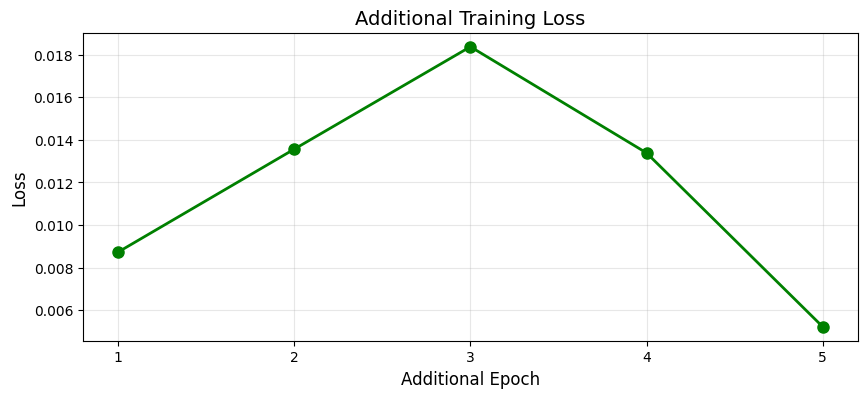


🎯 Additional training completed!
📈 Total additional epochs: 5
📉 Loss reduction: 0.0035


In [34]:
# %% Cell 13: Resume Training Function (Corrected with Data Collator)
from torch.utils.data import DataLoader
from torch.optim import AdamW
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def continue_training(model, processor, train_dataset, test_dataset,
                      additional_epochs=2, batch_size=4, learning_rate=5e-5,
                      data_collator=None):
    """
    استئناف تدريب النموذج المحمل لعدد إضافي من الـ Epochs

    Parameters:
    -----------
    model : النموذج المحمل
    processor : المعالج
    train_dataset : بيانات التدريب
    test_dataset : بيانات الاختبار
    additional_epochs : عدد الـ epochs الإضافية
    batch_size : حجم الـ batch
    learning_rate : معدل التعلم
    data_collator : Data collator للتعامل مع padding (مطلوب!)
    """
    print(f"\n🔄 Resuming training for {additional_epochs} more epochs...")
    print(f"📊 Train dataset size: {len(train_dataset)}")
    print(f"📊 Test dataset size: {len(test_dataset)}")

    # التحقق من وجود data_collator
    if data_collator is None:
        raise ValueError("❌ data_collator is required! Please provide a DataCollatorSpeechSeq2SeqWithPadding instance.")

    # إعداد DataLoader مع الـ collator المخصص
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=data_collator  # مهم جداً للتعامل مع الأطوال المختلفة
    )

    # محسن (Optimizer) مع معدل تعلم أقل للـ fine-tuning الإضافي
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    model.train()
    additional_losses = []
    device = next(model.parameters()).device

    print(f"🖥️  Training on device: {device}")
    print(f"📦 Number of batches per epoch: {len(train_loader)}")
    print("="*60)

    for epoch in range(additional_epochs):
        epoch_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Additional Epoch {epoch+1}/{additional_epochs}")

        for batch_idx, batch in enumerate(progress_bar):
            # نقل البيانات إلى الجهاز
            input_features = batch["input_features"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            outputs = model(input_features=input_features, labels=labels)
            loss = outputs.loss

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # تحديث شريط التقدم
            progress_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "avg": f"{epoch_loss/(batch_idx+1):.4f}"
            })

        avg_loss = epoch_loss / len(train_loader)
        additional_losses.append(avg_loss)
        print(f"\n✅ Additional Epoch {epoch+1} completed - Average Loss: {avg_loss:.4f}")
        print("-"*60)

    # رسم منحنى الخسارة الإضافية
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, additional_epochs+1), additional_losses,
             marker='o', linestyle='-', linewidth=2, markersize=8, color='green')
    plt.title("Additional Training Loss", fontsize=14)
    plt.xlabel("Additional Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, additional_epochs+1))
    plt.show()

    print(f"\n🎯 Additional training completed!")
    print(f"📈 Total additional epochs: {additional_epochs}")
    print(f"📉 Loss reduction: {additional_losses[0] - additional_losses[-1]:.4f}")

    return model, additional_losses

# التحقق من وجود data_collator
try:
    # إذا كان data_collator موجوداً من الخلايا السابقة
    if 'data_collator' not in globals():
        print("⚠️  Data collator not found. Creating a new one...")
        from dataclasses import dataclass
        from typing import Any, Dict, List, Union

        @dataclass
        class DataCollatorSpeechSeq2SeqWithPadding:
            processor: Any
            padding: Union[bool, str] = True
            max_length: int = None
            max_length_labels: int = None
            pad_to_multiple_of: int = None
            pad_to_multiple_of_labels: int = None

            def __call__(self, features: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
                # فصل input_features و labels
                input_features = [{"input_features": feature["input_features"]} for feature in features]
                label_features = [{"input_ids": feature["labels"]} for feature in features]

                # عمل padding للـ input_features
                batch = self.processor.feature_extractor.pad(
                    input_features,
                    padding=self.padding,
                    max_length=self.max_length,
                    pad_to_multiple_of=self.pad_to_multiple_of,
                    return_tensors="pt",
                )

                # عمل padding للـ labels
                labels_batch = self.processor.tokenizer.pad(
                    label_features,
                    padding=self.padding,
                    max_length=self.max_length_labels,
                    pad_to_multiple_of=self.pad_to_multiple_of_labels,
                    return_tensors="pt",
                )

                # استبدال padding token بـ -100 ليتم تجاهله في حساب الـ loss
                labels = labels_batch["input_ids"].masked_fill(
                    labels_batch.attention_mask.ne(1), -100
                )

                batch["labels"] = labels

                return batch

        # إنشاء Data Collator جديد
        data_collator = DataCollatorSpeechSeq2SeqWithPadding(
            processor=processor,
            padding=True
        )
        print("✅ New data collator created")

    # استئناف التدريب لـ 5 Epochs إضافية
    additional_epochs = 5
    model, new_losses = continue_training(
        model,
        processor,
        train_dataset,
        test_dataset,
        additional_epochs=additional_epochs,
        batch_size=4,
        learning_rate=5e-5,  # معدل تعلم أقل للـ fine-tuning
        data_collator=data_collator  # تمرير الـ collator
    )

except Exception as e:
    print(f"❌ Error: {e}")
    print("\n💡 Please make sure you have run Cell 7 first to create the data_collator!")

In [ ]:
#pip install jiwer

In [35]:
# %% Cell 14: Evaluate After Additional Training (Enhanced)
from jiwer import wer, cer
import torch

def evaluate_after_continued_training(model, processor, test_dataset, num_samples=30):
    """
    تقييم النموذج بعد استئناف التدريب
    """
    model.eval()
    predictions = []
    references = []

    # تقييم على عينة من بيانات الاختبار
    num_samples = min(num_samples, len(test_dataset))
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    device = next(model.parameters()).device

    print(f"\n📈 Evaluating model on {len(indices)} test samples...")
    print("="*60)

    for idx in tqdm(indices, desc="Evaluating"):
        sample = test_dataset[int(idx)]
        input_features = sample["input_features"].unsqueeze(0).to(device)
        label_ids = sample["labels"]

        # إزالة قيم -100 (padding tokens) من الـ labels قبل فك التشفير
        label_ids_clean = label_ids[label_ids != -100]

        # النص المرجعي
        ref_text = processor.decode(label_ids_clean, skip_special_tokens=True)

        # النص المتوقع
        with torch.no_grad():
            generated_ids = model.generate(
                input_features,
                language="arabic",
                task="transcribe",
                max_length=448,  # زيادة الحد الأقصى للنصوص الطويلة
                num_beams=1,  # greedy decoding (أسرع)
                early_stopping=True
            )
        pred_text = processor.decode(generated_ids[0], skip_special_tokens=True)

        predictions.append(pred_text)
        references.append(ref_text)

    # حساب المقاييس
    new_wer = wer(references, predictions)
    new_cer = cer(references, predictions)

    print(f"\n📊 Evaluation Results After Additional Training:")
    print(f"📈 Word Error Rate (WER): {new_wer:.4f}")
    print(f"📈 Character Error Rate (CER): {new_cer:.4f}")

    # مقارنة مع النتيجة السابقة إذا كانت متوفرة
    if 'old_checkpoint' in globals() and 'wer_score' in old_checkpoint:
        old_wer = old_checkpoint['wer_score']
        improvement = old_wer - new_wer
        print(f"\n📉 Previous WER: {old_wer:.4f}")
        if improvement > 0:
            print(f"📉 Improvement: {improvement:.4f} ({improvement/old_wer*100:.1f}% relative improvement)")
        else:
            print(f"📈 Regression: {abs(improvement):.4f} ({abs(improvement)/old_wer*100:.1f}% worse)")

    # عرض أمثلة محسنة
    print("\n🎯 Sample Predictions After Additional Training:")
    print("="*60)
    for i in range(min(5, len(predictions))):
        print(f"\n📝 Example {i+1}:")
        print(f"REF : {references[i]}")
        print(f"PRED: {predictions[i]}")
        # حساب WER لهذه العينة فقط
        sample_wer = wer(references[i], predictions[i])
        print(f"WER for this sample: {sample_wer:.4f}")
        print("-" * 60)

    return new_wer, new_cer

# تقييم النموذج
final_wer, final_cer = evaluate_after_continued_training(model, processor, test_dataset)


📈 Evaluating model on 30 test samples...


Evaluating: 100%|██████████| 30/30 [00:07<00:00,  4.22it/s]


📊 Evaluation Results After Additional Training:
📈 Word Error Rate (WER): 0.7818
📈 Character Error Rate (CER): 0.4508

📉 Previous WER: 1.1290
📉 Improvement: 0.3472 (30.8% relative improvement)

🎯 Sample Predictions After Additional Training:

📝 Example 1:
REF : [music]
PRED: كل واحده، 
WER for this sample: 2.0000
------------------------------------------------------------

📝 Example 2:
REF : أنا تعست كل اللي حواليا و أنا فاكر ان أنا بسعدهم. 
PRED: أنا اتعاست كل اللي حواليا و نفكر ان أنا بسعد بيه. 
WER for this sample: 0.4545
------------------------------------------------------------

📝 Example 3:
REF : مبيسمعش بتنده مين. 
PRED: اسناش تنضوا مش ايه؟ 
WER for this sample: 1.3333
------------------------------------------------------------

📝 Example 4:
REF : اهدى ازاي بس يا سعد بقولك خالد فص ملح و داب عارف ده معناه ايه؟
PRED: أخد اخلص بصمل حوضوع بعد ما عنيا. 
WER for this sample: 1.0000
------------------------------------------------------------

📝 Example 5:
REF : ايه الكلام الغريب د

In [36]:
# %% Cell 15: Simple Save and Download (What You Actually Need)
import shutil
from google.colab import files
import datetime

# إنشاء اسم مميز للملف المحفوظ مع التاريخ والوقت
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"whisper-ar-egypt-continued_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# حفظ النموذج مع معلومات التدريب الإضافية
checkpoint = {
    'model_state_dict': model.state_dict(),
    'processor': processor,
    'model_config': model.config,
    'wer_score': final_wer,
    'cer_score': final_cer,
    'additional_epochs': additional_epochs,
    'timestamp': timestamp,
    'training_info': {
        'base_model': 'openai/whisper-tiny',
        'dataset': 'UBC-NLP/Casablanca (Egypt)',
        'continued_training': True
    }
}

# هذا هو الحفظ الوحيد الذي تحتاجه
torch.save(checkpoint, os.path.join(save_dir, "asr_model_continued.pt"))
print(f"✅ Model saved to {save_dir}/asr_model_continued.pt")

# ضغط المجلد
zip_filename = f"whisper-ar-continued_{timestamp}"
shutil.make_archive(zip_filename, 'zip', save_dir)

# تحميل الملف المضغوط
files.download(f"{zip_filename}.zip")

print(f"✅ Download started for {zip_filename}.zip")

✅ Model saved to whisper-ar-egypt-continued_20260418_094404/asr_model_continued.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started for whisper-ar-continued_20260418_094404.zip


In [37]:
print('\nCalculating WER on the test dataset...')
current_wer_score = evaluate_model(model, processor, test_dataset, num_samples=len(test_dataset))


Calculating WER on the test dataset...


Evaluating: 100%|██████████| 85/85 [00:21<00:00,  3.98it/s]

Word Error Rate (WER): 0.8198
Character Error Rate (CER): 0.4636

=== Sample Predictions ===
REF: ايوا يا سعد بس. 
PRED: ايوا يا سعد بس. 
----------------------------------------
REF: ده نصاب دولي و مطلوب القبض عليه ده سارق من البنوك مية مليون دولار.
PRED: هو ماكلف الأبدا عليه ده سرق من البنوك مية مية مليل ي دور؟
----------------------------------------
REF: أهلاً أهلاَ يا بشمهندس الوادي الجديد الحقيقة المشاريع اللي الجديدة في دماغي كتير انت عارف أنا الزراعة بالنسبالي يعني عندي مشروع مثلاَ زراعة البلح السوبر. 
PRED: احنا انا يا بسبوسة و دي جديد الحقيقة للمشاريع اللي جديدة في المخكيير تعرفانا اصرع بالسبريقة يعني ا عنده مشروع مزرات زراحات اللي بلح الثور ورق. 
----------------------------------------
